# 산불 및 소방 데이터 탐색적 분석 (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("한글 설정 완료!")

한글 설정 완료!


## 1. 데이터 불러오기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties

warnings.filterwarnings('ignore')

KOREAN_FONT_PROP = None

def set_korean_font():
    global KOREAN_FONT_PROP
    font_paths = [
        r'C:\\Windows\\Fonts\\malgun.ttf',
        r'C:\\Windows\\Fonts\\malgunbd.ttf',
        '/System/Library/Fonts/AppleSDGothicNeo.ttc',
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    ]
    font_names = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']

    for font_path in font_paths:
        if os.path.exists(font_path):
            font_manager.fontManager.addfont(font_path)
            KOREAN_FONT_PROP = FontProperties(fname=font_path)
            font_name = KOREAN_FONT_PROP.get_name()
            plt.rcParams['font.family'] = font_name
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False
            return font_name

    installed = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in font_names:
        if font_name in installed:
            KOREAN_FONT_PROP = FontProperties(family=font_name)
            plt.rcParams['font.family'] = font_name
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False
            return font_name

    plt.rcParams['axes.unicode_minus'] = False
    return None

def apply_korean_font_to_axis(ax):
    if KOREAN_FONT_PROP is None:
        return
    ax.title.set_fontproperties(KOREAN_FONT_PROP)
    ax.xaxis.label.set_fontproperties(KOREAN_FONT_PROP)
    ax.yaxis.label.set_fontproperties(KOREAN_FONT_PROP)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(KOREAN_FONT_PROP)
    for text in ax.texts:
        text.set_fontproperties(KOREAN_FONT_PROP)
    if ax.figure.axes and len(ax.figure.axes) > 1:
        for extra_ax in ax.figure.axes[1:]:
            extra_ax.title.set_fontproperties(KOREAN_FONT_PROP)
            extra_ax.xaxis.label.set_fontproperties(KOREAN_FONT_PROP)
            extra_ax.yaxis.label.set_fontproperties(KOREAN_FONT_PROP)
            for label in extra_ax.get_xticklabels() + extra_ax.get_yticklabels():
                label.set_fontproperties(KOREAN_FONT_PROP)

# Seaborn 스타일을 먼저 적용한 뒤 한글 폰트를 마지막에 설정해야 덮어쓰이지 않습니다.
sns.set_theme(style='whitegrid', palette='husl')
korean_font = set_korean_font()

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['patch.linewidth'] = 0.5

if korean_font:
    print(f'한글 폰트 설정 완료: {korean_font}')
else:
    print('한글 폰트를 찾지 못했습니다. Windows는 맑은 고딕, macOS는 AppleGothic, Linux는 NanumGothic 설치를 확인하세요.')

# 데이터 경로 설정
data_path = '../data/processed/'

# 각 CSV 파일 로드
df_fire_location = pd.read_csv(data_path + '산불발생위치도_지형특성계산.csv')
df_fire_extinguish = pd.read_csv(data_path + '전국_산불소화시설.csv')
df_fire_station = pd.read_csv(data_path + '전국_소방서_좌표.csv')
df_water_facility = pd.read_csv(data_path + '전국_소방용수시설.csv')
df_forest_road = pd.read_csv(data_path + '전국_임도망도.csv')

print('데이터 로드 완료')
print(f'- 산불발생위치도: {df_fire_location.shape}')
print(f'- 산불소화시설: {df_fire_extinguish.shape}')
print(f'- 소방서 좌표: {df_fire_station.shape}')
print(f'- 소방용수시설: {df_water_facility.shape}')
print(f'- 임도망도: {df_forest_road.shape}')

print(f'\n현재 사용 폰트: {plt.rcParams["font.family"]}')
print(f'폰트 파일 직접 지정: {KOREAN_FONT_PROP.get_file() if KOREAN_FONT_PROP else None}')

한글 폰트 설정 완료: Malgun Gothic
데이터 로드 완료
- 산불발생위치도: (25036, 9)
- 산불소화시설: (187, 11)
- 소방서 좌표: (1216, 7)
- 소방용수시설: (192030, 8)
- 임도망도: (3322, 22)

현재 사용 폰트: ['Malgun Gothic']
폰트 파일 직접 지정: C:\\Windows\\Fonts\\malgun.ttf


## 2. 데이터 살펴보기 - 산불발생위치도

In [3]:
print("=" * 50)
print("산불발생위치도 데이터 정보")
print("=" * 50)
print(f"\n데이터셋 크기: {df_fire_location.shape}")
print(f"\n컬럼: {df_fire_location.columns.tolist()}")
print("\n데이터 유형:")
print(df_fire_location.dtypes)
print("\n처음 5행:")
print(df_fire_location.head())
print("\n데이터 정보:")
print(df_fire_location.info())

산불발생위치도 데이터 정보

데이터셋 크기: (25036, 9)

컬럼: ['fire_id', '위도', '경도', '고도(m)', '경사도(도)', '사면방향_sin', '사면방향_cos', 'TPI(지형위치지수)', 'TWI(지형다습지수)']

데이터 유형:
fire_id            str
위도             float64
경도             float64
고도(m)          float64
경사도(도)         float64
사면방향_sin       float64
사면방향_cos       float64
TPI(지형위치지수)    float64
TWI(지형다습지수)    float64
dtype: object

처음 5행:
    fire_id         위도          경도       고도(m)     경사도(도)  사면방향_sin  사면방향_cos  \
0  F_000000  37.635100  126.997582  233.925380  19.854153 -0.998277 -0.058677   
1  F_000001  37.450793  127.069168  121.872080   8.362768  0.059167 -0.998248   
2  F_000002  37.681290  127.016965  274.507260  17.241868 -0.874421  0.485168   
3  F_000003  37.502707  127.147636   39.532635   5.510313 -0.429893  0.902880   
4  F_000004  37.617382  127.037494   76.686935  11.763594  0.932967  0.359961   

   TPI(지형위치지수)  TWI(지형다습지수)  
0    -2.599762     5.503641  
1     1.706253     2.001579  
2     0.766327     1.479498  
3     0.180145   

In [4]:
# 다른 데이터셋 빠른 확인
print("\n" + "=" * 50)
print("다른 데이터셋 요약")
print("=" * 50)

datasets = {
    '산불소화시설': df_fire_extinguish,
    '소방서': df_fire_station,
    '소방용수시설': df_water_facility,
    '임도망도': df_forest_road
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  - 크기: {df.shape}")
    print(f"  - 컬럼: {df.columns.tolist()}")
    print(f"  - 처음 3행:\n{df.head(3).to_string()}")


다른 데이터셋 요약

산불소화시설:
  - 크기: (187, 11)
  - 컬럼: ['경도', '위도', '원격제어', '관리기관1', '관리기관2', '보호대상구분', '보호대상물', '설치년도', '시도', '시군구', '상세주소']
  - 처음 3행:
           경도         위도 원격제어  관리기관1 관리기관2  보호대상구분  보호대상물  설치년도     시도  시군구         상세주소
0  127.013400  37.475780  불가능  서울특별시   서초구     문화재    대성사  2012  서울특별시  서초구   서초동 산140-1
1  127.099387  37.553812   가능  서울특별시   광진구  주요기반시설  주거밀집지  2013  서울특별시  광진구      구의동 3-3
2  127.097098  37.561146   가능  서울특별시   광진구  주요기반시설  주거밀집지  2013  서울특별시  광진구  중곡동 143-127

소방서:
  - 크기: (1216, 7)
  - 컬럼: ['소방서 및 안전센터명', '위도', '경도', '시도', '시군구', '상세주소', '상위 본부명']
  - 처음 3행:
         소방서 및 안전센터명         위도          경도     시도  시군구        상세주소    상위 본부명
0  수성소방서-수성-119 안전센터  35.856757  128.620850  대구광역시  수성구   들안로60길 30  대구소방안전본부
1  수성소방서-황금-119 안전센터  35.835493  128.626425  대구광역시  수성구  동대구로12길 41  대구소방안전본부
2  수성소방서-만촌-119 안전센터  35.855340  128.652108  대구광역시  수성구  달구벌대로 2658  대구소방안전본부

소방용수시설:
  - 크기: (192030, 8)
  - 컬럼: ['시설유형', '시설유형코드', '시도명', '시군구명', '소재지지번주소', '위도

## 3. 기초 통계 요약

In [5]:
print("산불발생위치도 - 수치형 변수 통계")
print("=" * 50)
print(df_fire_location.describe())

print("\n산불발생위치도 - 데이터타입별 분류")
numeric_cols = df_fire_location.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_fire_location.select_dtypes(include=['object']).columns

print(f"\n수치형 컬럼: {numeric_cols.tolist()}")
print(f"범주형 컬럼: {categorical_cols.tolist()}")

# 범주형 변수의 값 개수
if len(categorical_cols) > 0:
    print("\n범주형 변수 분포:")
    for col in categorical_cols[:5]:  # 처음 5개만
        print(f"\n{col}:")
        print(df_fire_location[col].value_counts())

산불발생위치도 - 수치형 변수 통계
                 위도            경도         고도(m)        경사도(도)      사면방향_sin  \
count  25036.000000  25036.000000  25036.000000  25036.000000  25036.000000   
mean      36.568682    127.870187    179.127337      8.114909     -0.033255   
std        1.096221      0.875604    174.315806      6.676965      0.728426   
min       33.226835    124.666241      0.000000      0.000000     -1.000000   
25%       35.673609    127.094735     53.101670      2.698098     -0.792517   
50%       36.573791    127.840009    125.079200      6.417335     -0.062320   
75%       37.502494    128.616990    245.591088     12.046538      0.706597   
max       39.139419    130.910034   1643.591000     43.019516      1.000000   

           사면방향_cos   TPI(지형위치지수)   TWI(지형다습지수)  
count  25036.000000  25036.000000  2.318200e+04  
mean       0.158458     -0.409885  2.095722e+08  
std        0.665748      4.487153  5.420258e+08  
min       -1.000000    -27.624725  6.358774e-01  
25%       -0.40040

## 4. 결측값 분석

**이 시각화가 말하는 것**

산불발생위치도 데이터에 결측값이 어느 정도 있는지 확인하는 그래프입니다. 결측값이 많은 변수는 산불 위험도 분석에 바로 사용하기 어려우므로, 데이터 정제나 제외 여부를 판단하기 위한 기초 점검입니다.

모든 데이터셋 결측값 현황

산불소화시설 - 결측값 있음:
         컬럼명  결측값개수  결측값율(%)
관리기관2  관리기관2      1     0.53
시군구      시군구      6     3.21

소방서 - 결측값 있음:
     컬럼명  결측값개수  결측값율(%)
시군구  시군구     22     1.81

소방용수시설 - 결측값 있음:
             컬럼명   결측값개수  결측값율(%)
시설유형        시설유형  192030   100.00
소재지지번주소  소재지지번주소   24374    12.69

임도망도 - 결측값 있음:
               컬럼명  결측값개수  결측값율(%)
기타특이사항내용  기타특이사항내용   2788    83.93
테마임도          테마임도   3213    96.72
테마임도구분      테마임도구분   3212    96.69
테마임도지정년도  테마임도지정년도   3212    96.69

산불발생위치도 결측값 히트맵


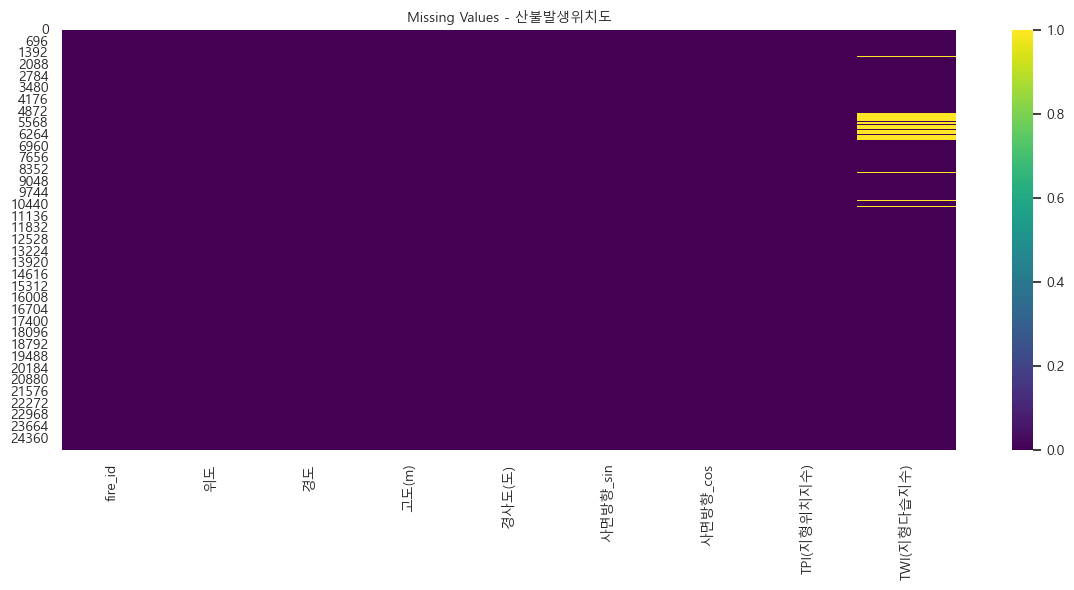

In [6]:
korean_font = set_korean_font() if 'set_korean_font' in globals() else None

if 'apply_korean_font_to_axis' not in globals():
    def apply_korean_font_to_axis(ax):
        return

print("모든 데이터셋 결측값 현황")
print("=" * 50)

for name, df in datasets.items():
    df_analysis = pd.DataFrame({
        '컬럼명': df.columns,
        '결측값개수': df.isnull().sum(),
        '결측값율(%)': (df.isnull().sum() / len(df) * 100).round(2)
    })
    
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"\n{name} - 결측값 있음:")
        print(df_analysis[df_analysis['결측값개수'] > 0])
    else:
        print(f"\n{name} - 결측값 없음 ✓")

# 산불발생위치도 결측값 시각화
print("\n" + "=" * 50)
print("산불발생위치도 결측값 히트맵")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_fire_location.isnull(), cbar=True, cmap='viridis', ax=ax)
ax.set_title('Missing Values - 산불발생위치도', fontproperties=KOREAN_FONT_PROP)
apply_korean_font_to_axis(ax)
apply_korean_font_to_axis(ax)
plt.tight_layout()
plt.show()

## 5. 변수 분포 시각화

**이 시각화가 말하는 것**

위도, 경도, 고도, 경사도 같은 수치형 변수의 분포를 보여줍니다. 이를 통해 산불 발생 위치가 어떤 공간적, 지형적 특성에 많이 분포하는지 확인할 수 있습니다. 박스플롯은 값이 특정 범위에 몰려 있는지, 또는 이상치가 존재하는지를 보기 위한 용도입니다.

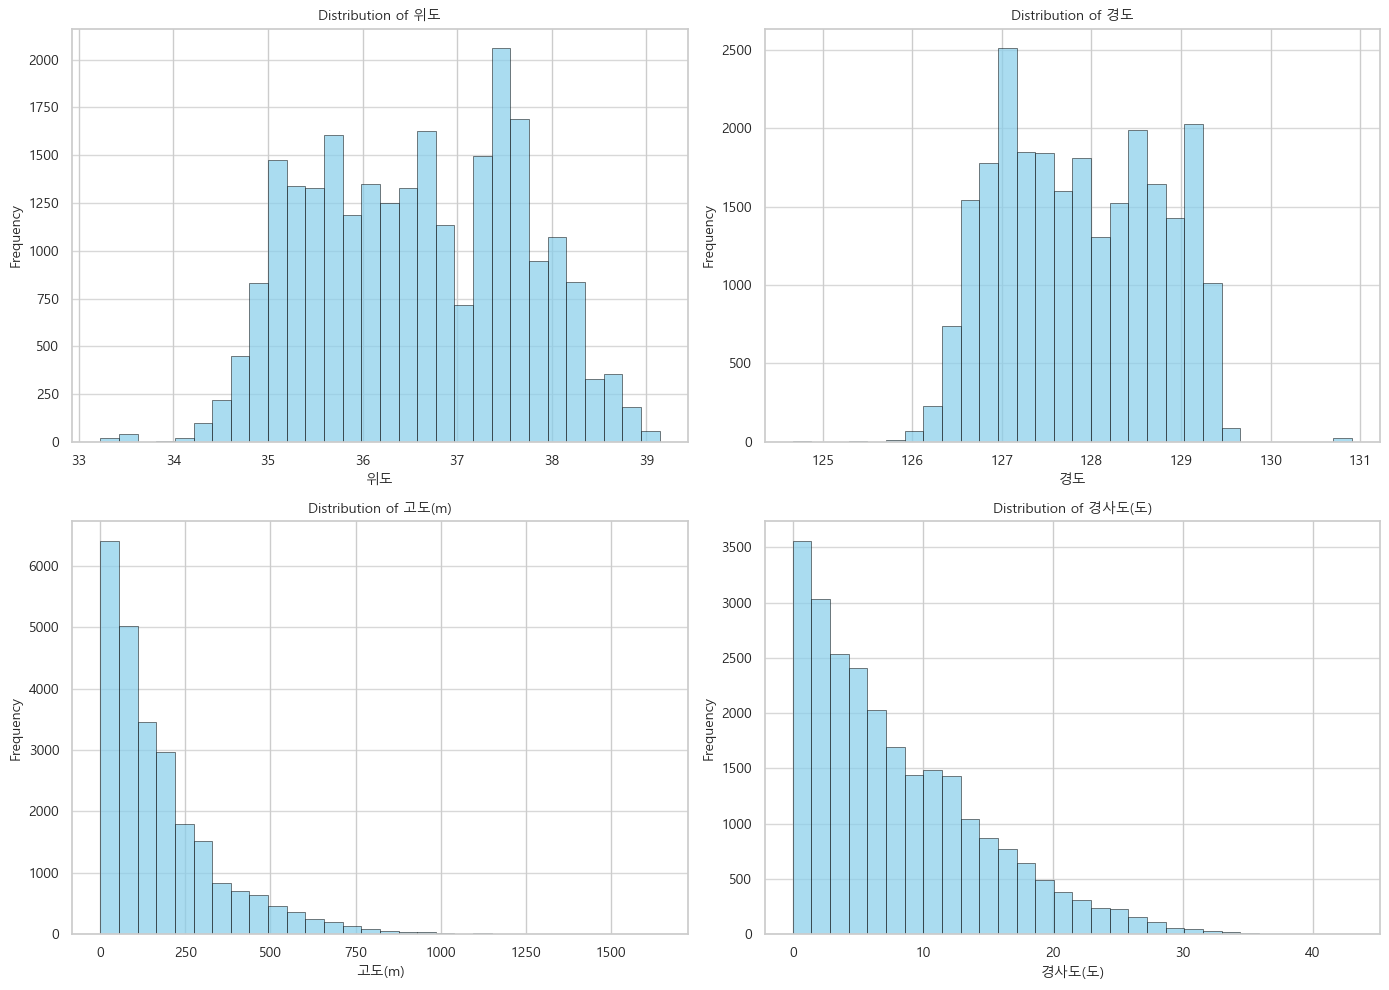

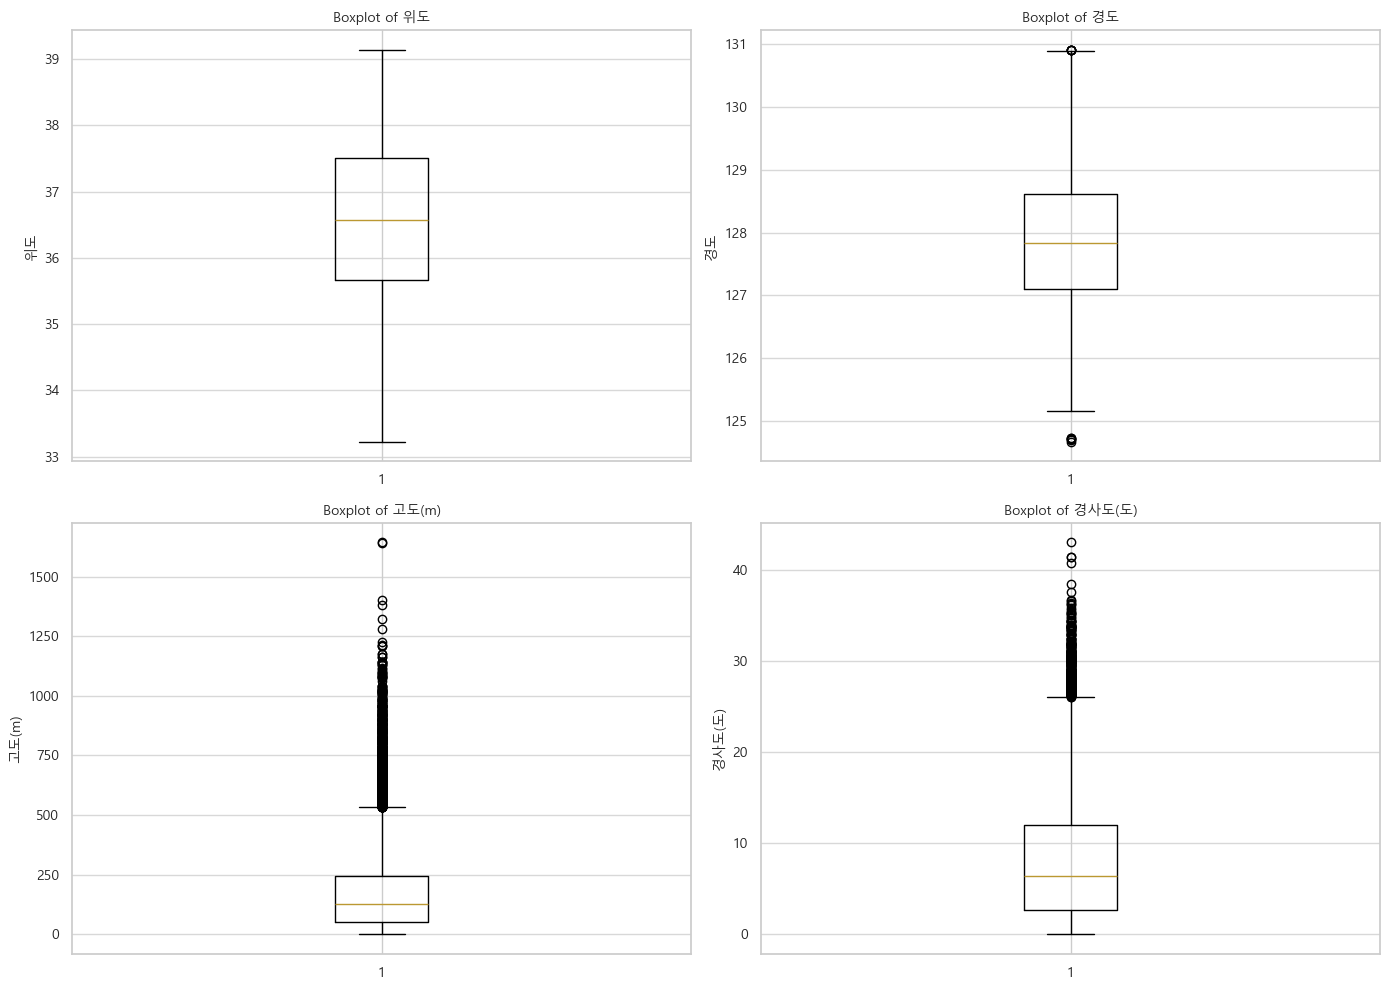

In [7]:
korean_font = set_korean_font() if 'set_korean_font' in globals() else None

if 'apply_korean_font_to_axis' not in globals():
    def apply_korean_font_to_axis(ax):
        return

# 산불발생위치도의 수치형 변수 분포
numeric_cols_fire = df_fire_location.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols_fire) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(numeric_cols_fire[:4]):
        axes[idx].hist(df_fire_location[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.75)
        apply_korean_font_to_axis(axes[idx])
    
    plt.tight_layout()
    plt.show()

# 박스플롯으로 이상치 시각화
if len(numeric_cols_fire) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(numeric_cols_fire[:4]):
        axes[idx].boxplot(df_fire_location[col].dropna())
        axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.75)
        apply_korean_font_to_axis(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 6. 변수 간 관계 분석

**이 시각화가 말하는 것**

고도, 경사도, TPI, TWI 등 지형 변수들이 서로 어떤 관계를 가지는지 보여줍니다. 예를 들어 고도와 경사도가 같이 움직이는지, 특정 지형 지표가 다른 지표와 연결되는지를 확인해 산불 발생 위치의 지형적 특성을 해석하는 데 도움을 줍니다.

산불발생위치도 - 수치형 변수 상관관계


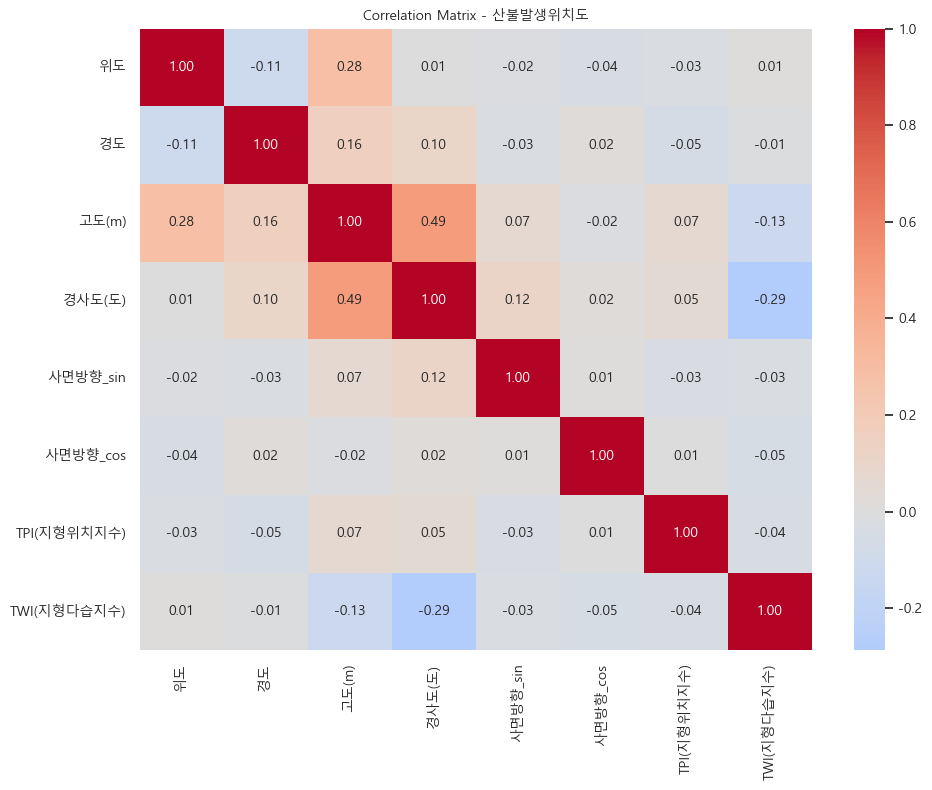


상관관계 매트릭스:
                   위도        경도     고도(m)    경사도(도)  사면방향_sin  사면방향_cos  \
위도           1.000000 -0.111974  0.282482  0.005872 -0.019796 -0.042126   
경도          -0.111974  1.000000  0.160354  0.104891 -0.029675  0.018597   
고도(m)        0.282482  0.160354  1.000000  0.489326  0.068061 -0.016858   
경사도(도)       0.005872  0.104891  0.489326  1.000000  0.120151  0.020749   
사면방향_sin    -0.019796 -0.029675  0.068061  0.120151  1.000000  0.013277   
사면방향_cos    -0.042126  0.018597 -0.016858  0.020749  0.013277  1.000000   
TPI(지형위치지수) -0.028139 -0.051595  0.067917  0.050930 -0.031786  0.006397   
TWI(지형다습지수)  0.010120 -0.011964 -0.125711 -0.287010 -0.025158 -0.049012   

             TPI(지형위치지수)  TWI(지형다습지수)  
위도             -0.028139     0.010120  
경도             -0.051595    -0.011964  
고도(m)           0.067917    -0.125711  
경사도(도)          0.050930    -0.287010  
사면방향_sin       -0.031786    -0.025158  
사면방향_cos        0.006397    -0.049012  
TPI(지형위치지수)     1.000000    -0.0

In [8]:
korean_font = set_korean_font() if 'set_korean_font' in globals() else None

if 'apply_korean_font_to_axis' not in globals():
    def apply_korean_font_to_axis(ax):
        return

# 상관관계 분석
print("산불발생위치도 - 수치형 변수 상관관계")
print("=" * 50)

numeric_df = df_fire_location.select_dtypes(include=['int64', 'float64'])
if len(numeric_df.columns) > 1:
    corr_matrix = numeric_df.corr()
    
    # 상관관계 히트맵
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Correlation Matrix - 산불발생위치도', fontproperties=KOREAN_FONT_PROP)
    apply_korean_font_to_axis(ax)
    apply_korean_font_to_axis(ax)
    plt.tight_layout()
    plt.show()
    
    print("\n상관관계 매트릭스:")
    print(corr_matrix)
else:
    print("수치형 변수가 충분하지 않습니다.")

## 7. 이상치 탐지

**이 분석이 말하는 것**

IQR과 Z-score를 사용해 수치형 변수의 이상치를 확인합니다. 이상치가 많은 변수는 평균이나 상관관계 분석 결과를 왜곡할 수 있으므로, 후속 분석에서 보정하거나 따로 해석할 필요가 있습니다.

In [9]:
def detect_outliers_iqr(data, column):
    """IQR 방법으로 이상치 탐지"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=3):
    """Z-score 방법으로 이상치 탐지"""
    z_scores = np.abs((data[column] - data[column].mean()) / data[column].std())
    outliers = data[z_scores > threshold]
    return outliers

# 산불발생위치도 이상치 분석
print("산불발생위치도 - 이상치 탐지 (IQR 방법)")
print("=" * 50)

numeric_cols_analysis = df_fire_location.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols_analysis[:3]:  # 처음 3개 컬럼만
    outliers_iqr, lower, upper = detect_outliers_iqr(df_fire_location, col)
    print(f"\n{col}:")
    print(f"  - 하한: {lower:.2f}, 상한: {upper:.2f}")
    print(f"  - 이상치 개수 (IQR): {len(outliers_iqr)}")
    
    # Z-score 방법
    outliers_zscore = detect_outliers_zscore(df_fire_location, col)
    print(f"  - 이상치 개수 (Z-score): {len(outliers_zscore)}")

print("\n" + "=" * 50)
print("각 데이터셋별 이상치 요약")
print("=" * 50)

for name, df in datasets.items():
    numeric_cols_temp = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_cols_temp) > 0:
        print(f"\n{name}:")
        for col in numeric_cols_temp[:2]:
            outliers, _, _ = detect_outliers_iqr(df, col)
            print(f"  - {col}: {len(outliers)} 이상치")

산불발생위치도 - 이상치 탐지 (IQR 방법)

위도:
  - 하한: 32.93, 상한: 40.25
  - 이상치 개수 (IQR): 0
  - 이상치 개수 (Z-score): 7

경도:
  - 하한: 124.81, 상한: 130.90
  - 이상치 개수 (IQR): 11
  - 이상치 개수 (Z-score): 31

고도(m):
  - 하한: -235.63, 상한: 534.33
  - 이상치 개수 (IQR): 1330
  - 이상치 개수 (Z-score): 446

각 데이터셋별 이상치 요약

산불소화시설:
  - 경도: 0 이상치
  - 위도: 0 이상치

소방서:
  - 위도: 0 이상치
  - 경도: 0 이상치

소방용수시설:
  - 시설유형: 0 이상치
  - 시설유형코드: 14395 이상치

임도망도:
  - 이력관리번호: 0 이상치
  - 임도시설거리: 312 이상치


## 8. 최종 요약 및 인사이트

In [10]:
print("=" * 70)
print("EDA 최종 요약 - 산불 및 소방 데이터")
print("=" * 70)

summary_data = []
for name, df in {'산불발생위치도': df_fire_location, **datasets}.items():
    summary_data.append({
        '데이터셋': name,
        '행': df.shape[0],
        '열': df.shape[1],
        '결측값': df.isnull().sum().sum(),
        '메모리사용(MB)': df.memory_usage(deep=True).sum() / 1024**2
    })

summary_df = pd.DataFrame(summary_data)
print("\n데이터셋 요약:")
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("주요 인사이트 및 다음 단계:")
print("=" * 70)
print("""
1. 데이터 특성:
   - 산불발생위치도: 산불 발생 위치 및 지형 특성 정보 포함
   - 소방 관련 데이터: 산불 소화시설, 소방서, 소방용수시설, 임도망도

2. 데이터 품질:
   - 결측값 현황을 확인하고 필요시 전처리 필요
   - 이상치의 존재 여부 및 처리 방안 검토

3. 공간 분석 가능성:
   - 좌표 정보를 활용한 공간 분석 및 시각화 가능
   - 산불 위험도와 소방 시설 간의 공간적 관계 분석 가능

4. 다음 단계:
   - 데이터 전처리 및 정제
   - 지도 기반 시각화 (Folium, Geopandas)
   - 변수 엔지니어링 및 모델링
""")

print("\nEDA 완료! 📊")
print("=" * 70)

EDA 최종 요약 - 산불 및 소방 데이터

데이터셋 요약:
   데이터셋      행  열    결측값  메모리사용(MB)
산불발생위치도  25036  9   1854   2.889145
 산불소화시설    187 11      7   0.112398
    소방서   1216  7     22   0.498497
 소방용수시설 192030  8 216404  65.955636
   임도망도   3322 22  12425  40.051457

주요 인사이트 및 다음 단계:

1. 데이터 특성:
   - 산불발생위치도: 산불 발생 위치 및 지형 특성 정보 포함
   - 소방 관련 데이터: 산불 소화시설, 소방서, 소방용수시설, 임도망도

2. 데이터 품질:
   - 결측값 현황을 확인하고 필요시 전처리 필요
   - 이상치의 존재 여부 및 처리 방안 검토

3. 공간 분석 가능성:
   - 좌표 정보를 활용한 공간 분석 및 시각화 가능
   - 산불 위험도와 소방 시설 간의 공간적 관계 분석 가능

4. 다음 단계:
   - 데이터 전처리 및 정제
   - 지도 기반 시각화 (Folium, Geopandas)
   - 변수 엔지니어링 및 모델링


EDA 완료! 📊


## 9. 소방용수시설 자치행정구역별 개수 비교

**이 시각화가 말하는 것**

`전국_소방용수시설.csv`의 `시도명`을 기준으로 자치행정구역별 소방용수시설 개수를 비교합니다. 강원특별자치도는 산림과 산불 위험이 큰 지역이므로, 다른 자치행정구역과 비교했을 때 소방용수 인프라 규모가 어느 정도인지 확인하는 그래프입니다.

전국_소방용수시설.csv 자치행정구역별 개수
 자치행정구역    개수      강원여부
  서울특별시 60705 다른 자치행정구역
    경기도 18361 다른 자치행정구역
   전라남도 12572 다른 자치행정구역
   경상북도 12049 다른 자치행정구역
   경상남도 11995 다른 자치행정구역
  부산광역시 10882 다른 자치행정구역
  인천광역시 10103 다른 자치행정구역
전북특별자치도  9587 다른 자치행정구역
강원특별자치도  9177   강원특별자치도
   충청남도  7752 다른 자치행정구역
  대구광역시  7073 다른 자치행정구역
   충청북도  6223 다른 자치행정구역
  광주광역시  4702 다른 자치행정구역
  울산광역시  3296 다른 자치행정구역
  대전광역시  3234 다른 자치행정구역
제주특별자치도  2684 다른 자치행정구역
세종특별자치시  1635 다른 자치행정구역


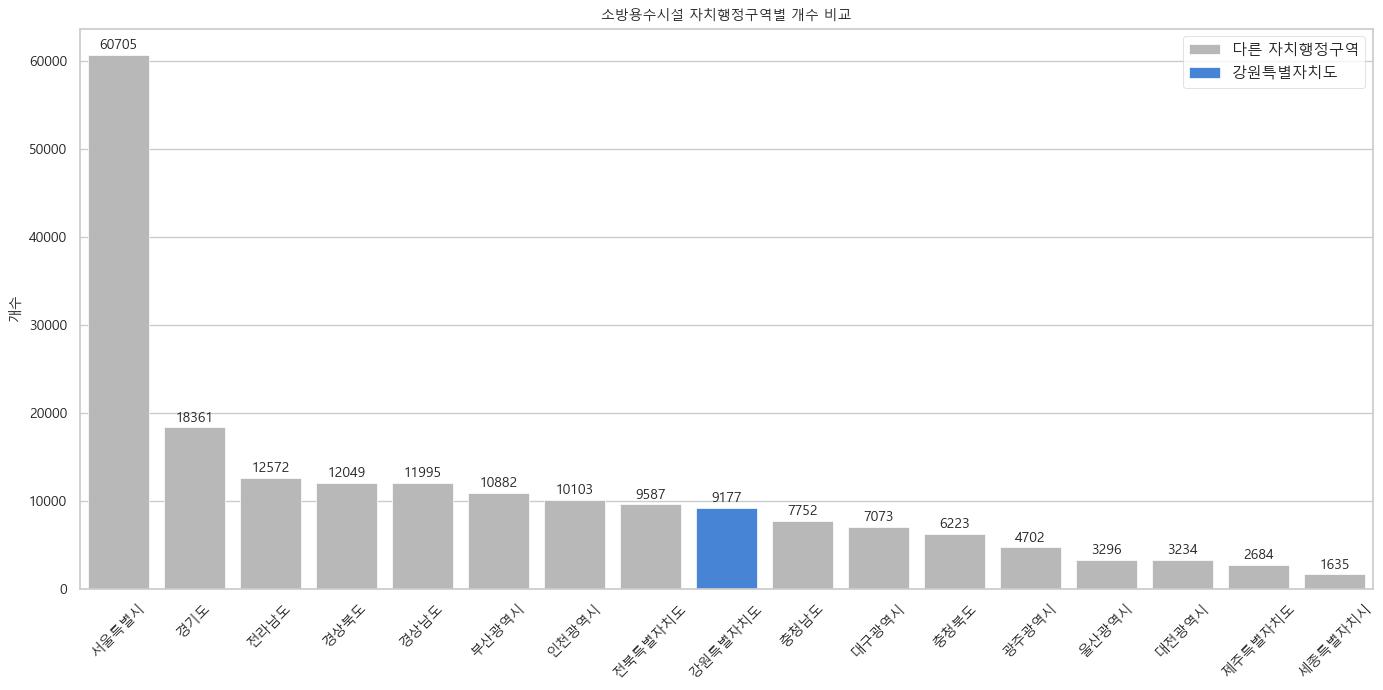

In [11]:
# 전국_소방용수시설.csv 기준: 자치행정구역(시도명)별 개수 비교
korean_font = set_korean_font() if 'set_korean_font' in globals() else None

water_region_count_df = (
    df_water_facility['시도명']
    .fillna('미상')
    .value_counts()
    .rename_axis('자치행정구역')
    .reset_index(name='개수')
)

water_region_count_df['강원여부'] = np.where(
    water_region_count_df['자치행정구역'].eq('강원특별자치도'),
    '강원특별자치도',
    '다른 자치행정구역'
)

print('전국_소방용수시설.csv 자치행정구역별 개수')
print(water_region_count_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=water_region_count_df,
    x='자치행정구역',
    y='개수',
    hue='강원여부',
    dodge=False,
    palette={
        '강원특별자치도': '#2f80ed',
        '다른 자치행정구역': '#b8b8b8'
    },
    ax=ax
)

ax.set_title('소방용수시설 자치행정구역별 개수 비교', fontproperties=KOREAN_FONT_PROP)
ax.set_xlabel('')
ax.set_ylabel('개수')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=8)

apply_korean_font_to_axis(ax)
plt.tight_layout()
plt.show()
